# 02 — Análise Exploratória dos Dados

Exploração da variável resposta e das variáveis explicativas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/dataset_vendedores.csv")
print(f"Dataset: {len(df):,} vendedores")

Dataset: 1,754 vendedores


## 1. Distribuição da variável resposta

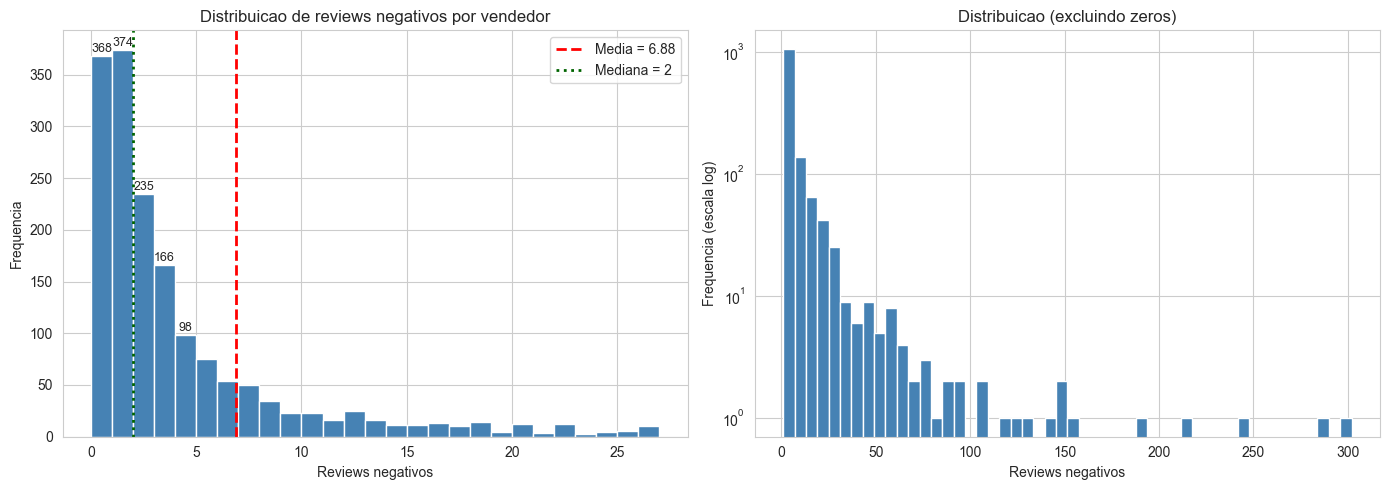

Media: 6.88, Variancia: 363.66, Var/Media: 52.90
Zeros: 368 (21.0%)


In [2]:
y = df["n_negative"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts, bins, patches = axes[0].hist(y, bins=range(0, min(int(y.quantile(0.95))+2, 50)), color="steelblue", edgecolor="white")
axes[0].set_xlabel("Reviews negativos")
axes[0].set_ylabel("Frequencia")
axes[0].set_title("Distribuicao de reviews negativos por vendedor")
media = y.mean()
mediana = y.median()
axes[0].axvline(media, color="red", linestyle="--", linewidth=2, label=f"Media = {media:.2f}")
axes[0].axvline(mediana, color="darkgreen", linestyle=":", linewidth=2, label=f"Mediana = {mediana:.0f}")
axes[0].legend()
for i in range(min(5, len(counts))):
    if counts[i] > 0:
        axes[0].text(bins[i] + (bins[i+1]-bins[i])/2, counts[i] + max(counts)*0.01,
                     f"{int(counts[i])}", ha="center", fontsize=9)

axes[1].hist(y[y > 0], bins=50, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Reviews negativos")
axes[1].set_ylabel("Frequencia (escala log)")
axes[1].set_title("Distribuicao (excluindo zeros)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("../outputs/eda_distribuicao_negativos.png", bbox_inches="tight", dpi=110)
plt.show()

print(f"Media: {y.mean():.2f}, Variancia: {y.var():.2f}, Var/Media: {y.var()/y.mean():.2f}")
print(f"Zeros: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")

## 2. Evolucao temporal da taxa de reviews negativos

Serie mensal da taxa de reviews negativos no periodo coberto pela base (2016-2018), calculada no nivel de pedido. Tem carater contextual: indica se a taxa de insatisfacao e estavel ao longo do tempo, o que ajuda a delimitar a generalizacao dos resultados.

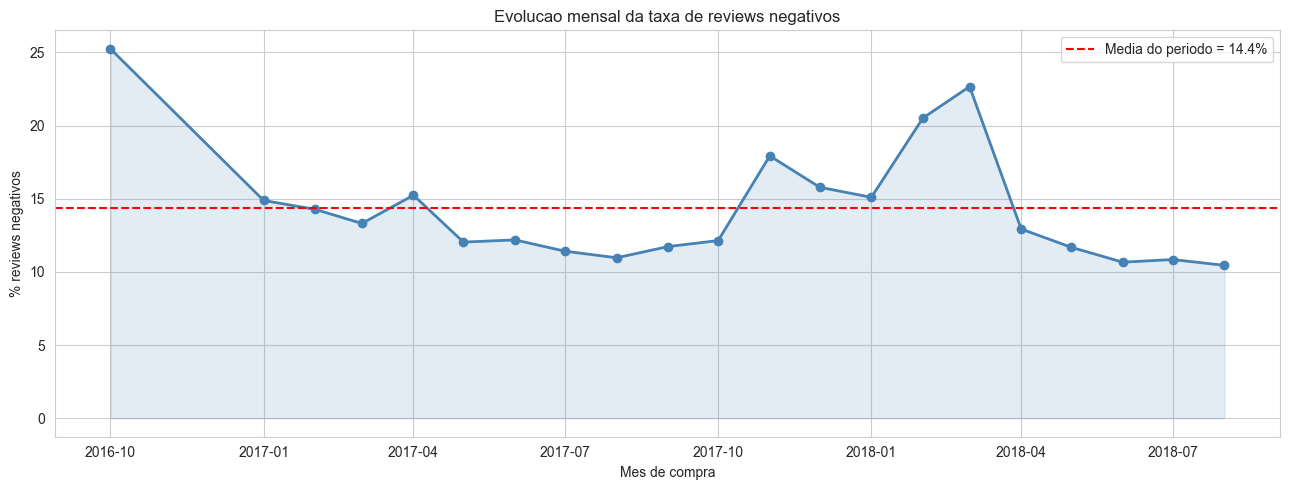

Taxa media do periodo: 14.4% | min 10.5% | max 25.2%


In [3]:
_orders = pd.read_csv("../data/olist_orders_dataset.csv", parse_dates=["order_purchase_timestamp"])
_items = pd.read_csv("../data/olist_order_items_dataset.csv")
_reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")

op = _orders.merge(_items[["order_id", "seller_id"]].drop_duplicates("order_id"), on="order_id")
op = op.merge(_reviews[["order_id", "review_score"]], on="order_id")
op["is_negative"] = (op["review_score"] <= 2).astype(int)
op["mes"] = op["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

monthly = op.groupby("mes").agg(total=("is_negative", "count"), negativos=("is_negative", "sum")).reset_index()
monthly["pct"] = monthly["negativos"] / monthly["total"] * 100
monthly = monthly[monthly["total"] >= 100]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly["mes"], monthly["pct"], color="steelblue", linewidth=2, marker="o")
ax.fill_between(monthly["mes"], monthly["pct"], alpha=0.15, color="steelblue")
ax.axhline(monthly["pct"].mean(), color="red", linestyle="--", label=f"Media do periodo = {monthly['pct'].mean():.1f}%")
ax.set_xlabel("Mes de compra"); ax.set_ylabel("% reviews negativos")
ax.set_title("Evolucao mensal da taxa de reviews negativos"); ax.legend()
plt.tight_layout()
plt.savefig("../outputs/eda_evolucao_temporal.png", bbox_inches="tight", dpi=110)
plt.show()

print(f"Taxa media do periodo: {monthly['pct'].mean():.1f}% | min {monthly['pct'].min():.1f}% | max {monthly['pct'].max():.1f}%")


## 3. Concentração da insatisfação — Curva de Lorenz

A curva de Lorenz mede o grau de concentração da contagem de reviews negativos entre os vendedores. Em marketplaces, é comum que um conjunto pequeno de lojistas responda por grande parte das reclamações.

Gini: 0.747
Top 20% concentram: 77.9% dos reviews negativos
Top 10% concentram: 62.8% dos reviews negativos


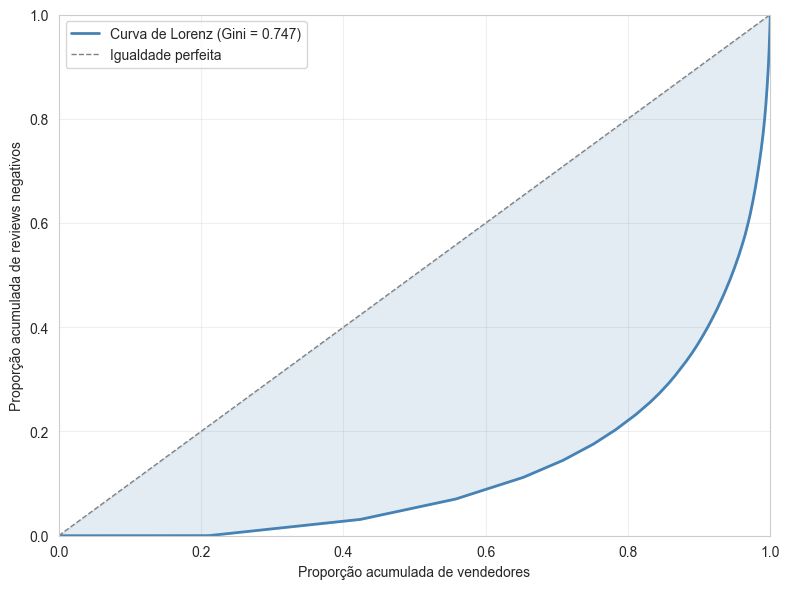

In [4]:
y_arr = pd.to_numeric(df["n_negative"], errors="coerce").fillna(0).clip(lower=0).to_numpy()
y_sorted = np.sort(y_arr)
n = len(y_sorted)
cum_share = np.cumsum(y_sorted) / y_sorted.sum()
pop_share = np.arange(1, n + 1) / n

gini = 1 - 2 * np.trapezoid(cum_share, pop_share)
p80 = np.interp(0.8, pop_share, cum_share)
p90 = np.interp(0.9, pop_share, cum_share)

print(f"Gini: {gini:.3f}")
print(f"Top 20% concentram: {(1 - p80) * 100:.1f}% dos reviews negativos")
print(f"Top 10% concentram: {(1 - p90) * 100:.1f}% dos reviews negativos")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(pop_share, cum_share, color="steelblue", linewidth=2, label=f"Curva de Lorenz (Gini = {gini:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Igualdade perfeita")
ax.fill_between(pop_share, cum_share, pop_share, color="steelblue", alpha=0.15)
ax.set_xlabel("Proporção acumulada de vendedores")
ax.set_ylabel("Proporção acumulada de reviews negativos")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.grid(True, alpha=0.3); ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/fig_lorenz.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Perfil dos piores versus melhores vendedores

Comparacao descritiva entre os 5% de vendedores com maior taxa de reviews negativos e os 5% com menor taxa, restrita a vendedores com pelo menos 20 reviews para estabilidade da taxa. Operacionaliza, em termos de perfil, a concentracao evidenciada pela curva de Lorenz.

In [5]:
df["taxa_neg_calc"] = df["n_negative"] / df["n_reviews"]
base = df[df["n_reviews"] >= 20]
k = int(len(df) * 0.05)
piores = base.nlargest(k, "taxa_neg_calc")
melhores = base.nsmallest(k, "taxa_neg_calc")

cols = ["taxa_neg_calc", "atraso_medio", "ticket_medio", "frete_medio", "peso_medio"]
comp = pd.DataFrame({"Pior 5%": piores[cols].mean(), "Melhor 5%": melhores[cols].mean()})
comp["Diferenca"] = comp["Pior 5%"] - comp["Melhor 5%"]
print(f"Comparacao 5% piores (n={len(piores)}) vs 5% melhores (n={len(melhores)}), min. 20 reviews:")
print(comp.round(3).to_string())
print("\nCategorias predominantes entre os piores:")
print(piores["categoria_principal"].value_counts().head(5).to_string())
print("\nCategorias predominantes entre os melhores:")
print(melhores["categoria_principal"].value_counts().head(5).to_string())


Comparacao 5% piores (n=87) vs 5% melhores (n=87), min. 20 reviews:
                Pior 5%  Melhor 5%  Diferenca
taxa_neg_calc     0.271      0.025      0.246
atraso_medio    -10.131    -13.648      3.516
ticket_medio    187.730    152.922     34.808
frete_medio      26.853     20.991      5.862
peso_medio     3149.762   1559.185   1590.578

Categorias predominantes entre os piores:
categoria_principal
furniture_decor          13
computers_accessories    10
bed_bath_table            8
sports_leisure            8
health_beauty             7

Categorias predominantes entre os melhores:
categoria_principal
housewares        11
health_beauty     11
baby               8
auto               6
sports_leisure     5


## 5. Reviews negativos vs atraso de entrega

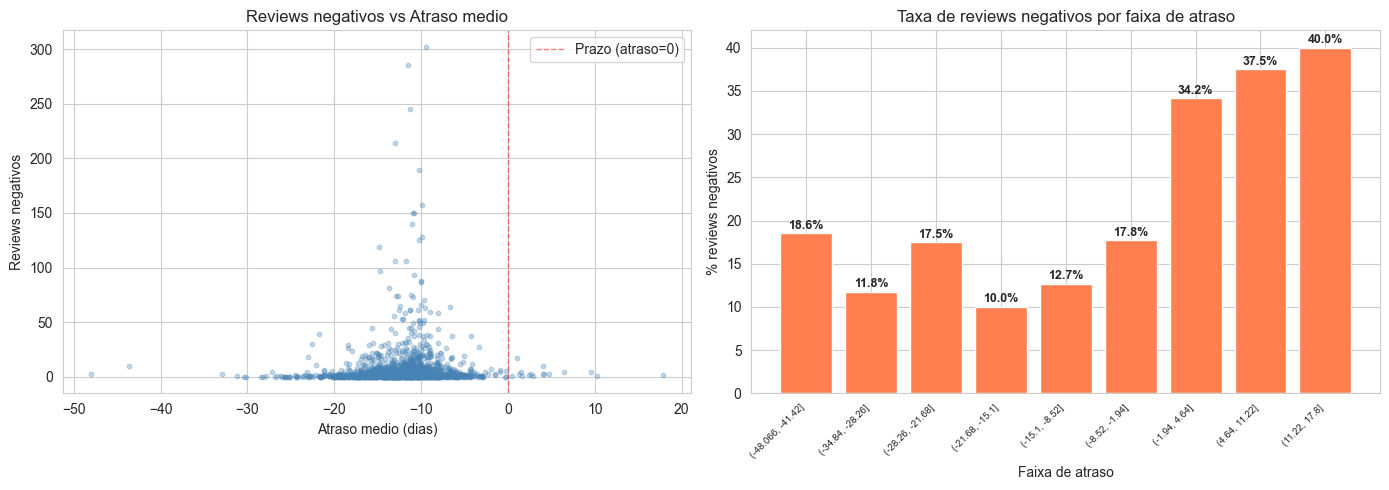

Correlacao n_negative vs atraso_medio: 0.051


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["atraso_medio"], df["n_negative"], alpha=0.3, s=10, color="steelblue")
axes[0].set_xlabel("Atraso medio (dias)")
axes[0].set_ylabel("Reviews negativos")
axes[0].set_title("Reviews negativos vs Atraso medio")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.5, label="Prazo (atraso=0)")
axes[0].legend()

df["atraso_bin"] = pd.cut(df["atraso_medio"], bins=10)
taxa = df.groupby("atraso_bin", observed=True).agg(
    taxa_neg=("n_negative", "sum"),
    n_reviews=("n_reviews", "sum")
).reset_index()
taxa["pct"] = taxa["taxa_neg"] / taxa["n_reviews"] * 100
bars = axes[1].bar(range(len(taxa)), taxa["pct"], color="coral", edgecolor="white")
axes[1].set_xlabel("Faixa de atraso")
axes[1].set_ylabel("% reviews negativos")
axes[1].set_title("Taxa de reviews negativos por faixa de atraso")
axes[1].set_xticks(range(len(taxa)))
axes[1].set_xticklabels([str(x) for x in taxa["atraso_bin"]], rotation=45, ha="right", fontsize=7)
for bar, val in zip(bars, taxa["pct"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/eda_negativos_vs_atraso.png", bbox_inches="tight", dpi=110)
plt.show()

corr_val = df["n_negative"].corr(df["atraso_medio"])
print(f"Correlacao n_negative vs atraso_medio: {corr_val:.3f}")

## 6. Reviews negativos por categoria

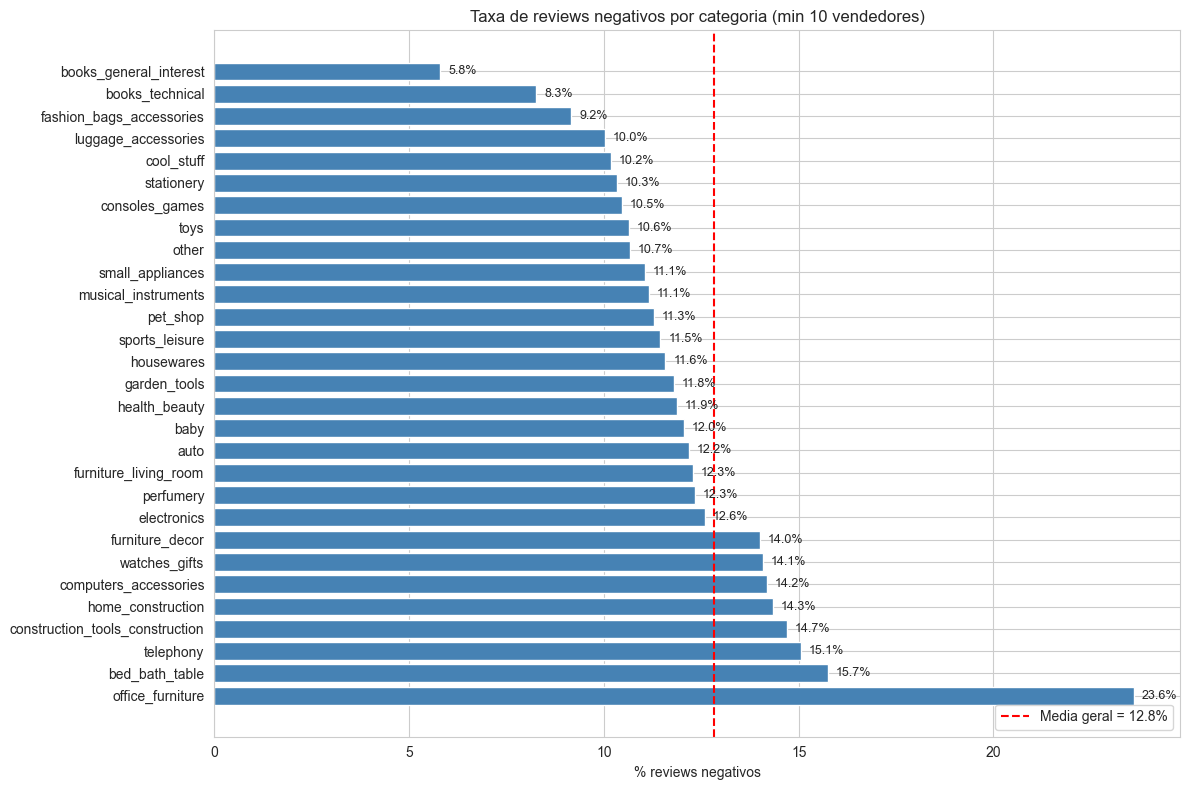

In [7]:
cat_stats = df.groupby("categoria_principal").agg(
    n_vendedores=("n_negative", "count"),
    neg_medio=("n_negative", "mean"),
    taxa_neg=("n_negative", "sum"),
    total_rev=("n_reviews", "sum")
).reset_index()
cat_stats["pct_neg"] = cat_stats["taxa_neg"] / cat_stats["total_rev"] * 100
cat_stats = cat_stats[cat_stats["n_vendedores"] >= 10].sort_values("pct_neg", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(cat_stats["categoria_principal"], cat_stats["pct_neg"], color="steelblue")
ax.set_xlabel("% reviews negativos")
ax.set_title("Taxa de reviews negativos por categoria (min 10 vendedores)")
media_geral = df["n_negative"].sum()/df["n_reviews"].sum()*100
ax.axvline(media_geral, color="red", linestyle="--", label=f"Media geral = {media_geral:.1f}%")
ax.legend(loc="lower right")
for bar, val in zip(bars, cat_stats["pct_neg"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/eda_negativos_por_categoria.png", bbox_inches="tight", dpi=110)
plt.show()

## 7. Reviews negativos por estado

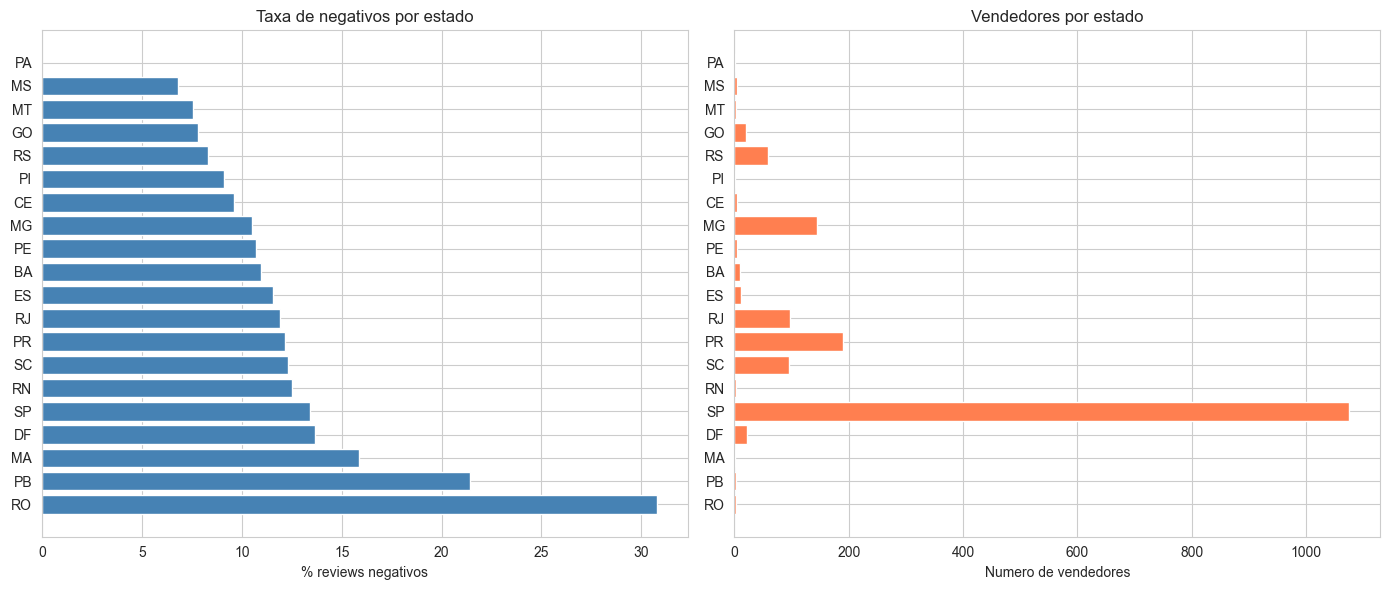

In [8]:
state_stats = df.groupby("seller_state").agg(
    n_vendedores=("n_negative", "count"),
    taxa_neg=("n_negative", "sum"),
    total_rev=("n_reviews", "sum")
).reset_index()
state_stats["pct_neg"] = state_stats["taxa_neg"] / state_stats["total_rev"] * 100
state_stats = state_stats.sort_values("pct_neg", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(state_stats["seller_state"], state_stats["pct_neg"], color="steelblue")
axes[0].set_xlabel("% reviews negativos")
axes[0].set_title("Taxa de negativos por estado")

axes[1].barh(state_stats["seller_state"], state_stats["n_vendedores"], color="coral")
axes[1].set_xlabel("Numero de vendedores")
axes[1].set_title("Vendedores por estado")

plt.tight_layout()
plt.savefig("../outputs/eda_negativos_por_estado.png", bbox_inches="tight")
plt.show()

## 8. Correlações entre variáveis contínuas

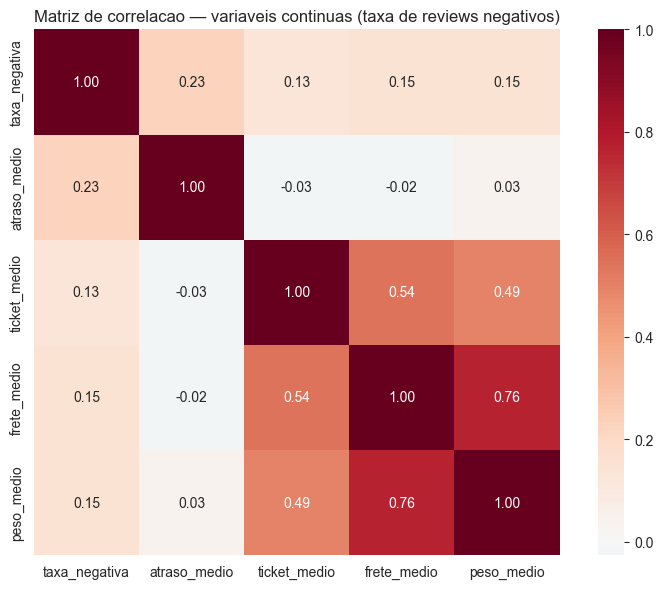

Correlacoes com taxa_negativa:
taxa_negativa    1.000000
atraso_medio     0.229576
frete_medio      0.149781
peso_medio       0.149608
ticket_medio     0.129009


In [9]:
df["taxa_negativa"] = df["n_negative"] / df["n_reviews"]

cont_vars = ["taxa_negativa", "atraso_medio", "ticket_medio", "frete_medio", "peso_medio"]
corr = df[cont_vars].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Matriz de correlacao — variaveis continuas (taxa de reviews negativos)")
plt.tight_layout()
plt.savefig("../outputs/eda_correlacao.png", bbox_inches="tight")
plt.show()

print("Correlacoes com taxa_negativa:")
print(corr["taxa_negativa"].sort_values(ascending=False).to_string())

## 9. Sobredispersão — verificação preliminar

In [10]:
media = y.mean()
variancia = y.var()
razao = variancia / media

print("=== Verificacao de sobredispersao ===")
print(f"Media:     {media:.2f}")
print(f"Variancia: {variancia:.2f}")
print(f"Razao V/M: {razao:.2f}")
print()
if razao > 1:
    print(f"Razao V/M = {razao:.2f} >> 1 --> Sobredispersao forte")
    print("Poisson inadequado. Binomial Negativa necessaria.")

=== Verificacao de sobredispersao ===
Media:     6.88
Variancia: 363.66
Razao V/M: 52.90

Razao V/M = 52.90 >> 1 --> Sobredispersao forte
Poisson inadequado. Binomial Negativa necessaria.


## 10. Verificação de multicolinearidade — VIF

Fator de Inflação da Variância (VIF) para as variáveis contínuas do modelo.
Variáveis com VIF > 10 são candidatas à exclusão (Fávero e Belfiore, 2024).

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

cont_cols = ["atraso_medio", "ticket_medio", "frete_medio", "peso_medio"]
# VIF exige a constante na matriz de design; sem ela os valores ficam distorcidos
X_vif = sm.add_constant(df[cont_cols].dropna())

vif_df = pd.DataFrame({
    "Variavel": cont_cols,
    "VIF": [variance_inflation_factor(X_vif.values, X_vif.columns.get_loc(c)) for c in cont_cols]
})

print("=== Fator de Inflacao da Variancia (VIF) — com constante ===")
print(vif_df.to_string(index=False))
print()
max_vif = vif_df["VIF"].max()
if max_vif < 10:
    print(f"VIF maximo = {max_vif:.2f}. Sem multicolinearidade problematica.")
else:
    print(f"ATENCAO: VIF maximo = {max_vif:.2f}.")


=== Fator de Inflacao da Variancia (VIF) — com constante ===
    Variavel      VIF
atraso_medio 1.007812
ticket_medio 1.443394
 frete_medio 2.632362
  peso_medio 2.474831

VIF maximo = 2.63. Sem multicolinearidade problematica.
